<a href="https://colab.research.google.com/github/Farzanqureshii/LAB-WORK/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BFS Search Result: True
DFS Search Result: True

========== TASK 2 ==========

Processing Size: 1000
Processing Size: 40000
Processing Size: 80000
Processing Size: 200000
Processing Size: 1000000

Results Table:

   Input Size  BFS Time (sec)  DFS Time (sec)
0        1000        0.000419        0.000213
1       40000        0.054108        0.050242
2       80000        0.063000        0.045634
3      200000        0.163702        0.059689
4     1000000        1.299080        0.066698


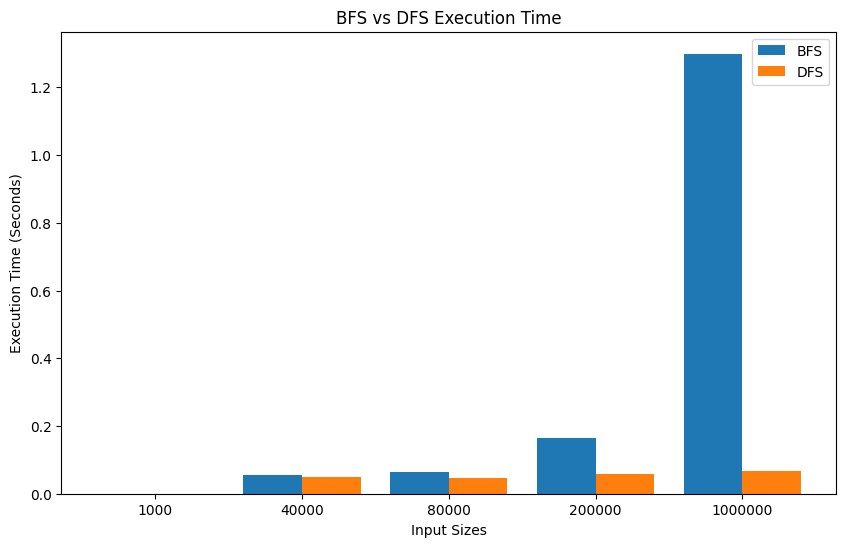


========== TASK 3 ==========

Shortest Path from Islamabad to Karachi:
Islamabad -> Rawalpindi -> Quetta -> Karachi


In [ ]:

import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt
# TASK 1
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                queue.append(neighbor)

    return False
def dfs(graph, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                stack.append(neighbor)

    return False
print("BFS Search Result:", bfs(graph, 'A', 'F'))
print("DFS Search Result:", dfs(graph, 'A', 'F'))
# TASK 2
print("\n========== TASK 2 ==========\n")

sizes = [1000, 40000, 80000, 200000, 1000000]

results = []
def build_tree(data):
    tree = {}

    for i in range(len(data)):
        left = 2 * i + 1
        right = 2 * i + 2

        children = []

        if left < len(data):
            children.append(data[left])

        if right < len(data):
            children.append(data[right])

        tree[data[i]] = children

    return tree

def bfs_tree(tree, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)

            for child in tree.get(node, []):
                queue.append(child)

    return False


# DFS for Tree
def dfs_tree(tree, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)

            for child in tree.get(node, []):
                stack.append(child)

    return False


for size in sizes:

    print(f"Processing Size: {size}")

    numbers = random.sample(range(size * 10), size)

    tree = build_tree(numbers)

    goal = numbers[len(numbers) - 220]

    start_node = numbers[0]

    start_time = time.time()
    bfs_tree(tree, start_node, goal)
    bfs_time = time.time() - start_time

    start_time = time.time()
    dfs_tree(tree, start_node, goal)
    dfs_time = time.time() - start_time

    # Store results
    results.append({
        'Input Size': size,
        'BFS Time (sec)': bfs_time,
        'DFS Time (sec)': dfs_time
    })

df = pd.DataFrame(results)

print("\nResults Table:\n")
print(df)

# Plot Bar Chart


x = range(len(sizes))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    df['BFS Time (sec)'],
    width=0.4,
    label='BFS'
)

plt.bar(
    [i + 0.2 for i in x],
    df['DFS Time (sec)'],
    width=0.4,
    label='DFS'
)

plt.xticks(x, sizes)

plt.xlabel("Input Sizes")
plt.ylabel("Execution Time (Seconds)")
plt.title("BFS vs DFS Execution Time")

plt.legend()

plt.show()


# TASK 3


print("\n========== TASK 3 ==========\n")

city_graph = {
    'Islamabad': ['Rawalpindi', 'Lahore', 'Peshawar'],
    'Rawalpindi': ['Islamabad', 'Peshawar', 'Quetta'],
    'Peshawar': ['Islamabad', 'Rawalpindi', 'Quetta'],
    'Lahore': ['Islamabad', 'Multan', 'Quetta'],
    'Multan': ['Lahore', 'Karachi', 'Quetta'],
    'Quetta': ['Rawalpindi', 'Peshawar', 'Multan', 'Karachi'],
    'Karachi': ['Multan', 'Quetta']
}


def bfs_shortest_path(graph, start, goal):

    visited = set()

    queue = deque([[start]])

    while queue:

        path = queue.popleft()

        node = path[-1]

        if node == goal:
            return path

        if node not in visited:

            visited.add(node)

            for neighbor in graph[node]:

                new_path = list(path)
                new_path.append(neighbor)

                queue.append(new_path)

    return None


shortest_path = bfs_shortest_path(
    city_graph,
    'Islamabad',
    'Karachi'
)

print("Shortest Path from Islamabad to Karachi:")
print(" -> ".join(shortest_path))